In [ ]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,roc_auc_score,roc_curve

sns.set(style="whitegrid",palette="muted")
plt.rcParams['figure.figsize']=(8,5)

In [ ]:
#load data
np.random.seed(42)
n=10000
data=pd.read_csv("/content/Bank_Churn_Classification_Dataset.csv")
data.head()

,Unnamed: 0,CustomerID,Gender,SeniorCitizen,Tenure,MonthlyCharges,Contract,PaymentMethod,Churn,TotalCharges
0,0,0,Male,0,55,111.88,Two year,Mailed check,0,6153.40
1,1,1,Female,1,36,58.70,Two year,Electronic check,0,2113.20
2,2,2,Male,0,37,118.86,One year,Electronic check,0,4397.82
3,3,3,Male,1,14,96.14,Month-to-month,Mailed check,1,1345.96
4,4,4,Male,1,27,28.05,Two year,Mailed check,0,757.35


In [ ]:
#dataset info
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      10000 non-null  int64  
 1   CustomerID      10000 non-null  int64  
 2   Gender          10000 non-null  object 
 3   SeniorCitizen   10000 non-null  int64  
 4   Tenure          10000 non-null  int64  
 5   MonthlyCharges  10000 non-null  float64
 6   Contract        10000 non-null  object 
 7   PaymentMethod   10000 non-null  object 
 8   Churn           10000 non-null  int64  
 9   TotalCharges    10000 non-null  float64
dtypes: float64(2), int64(5), object(3)
memory usage: 781.4+ KB
None


In [ ]:
#checking missing values
print(data.isnull().sum())

Unnamed: 0        0
CustomerID        0
Gender            0
SeniorCitizen     0
Tenure            0
MonthlyCharges    0
Contract          0
PaymentMethod     0
Churn             0
TotalCharges      0
dtype: int64


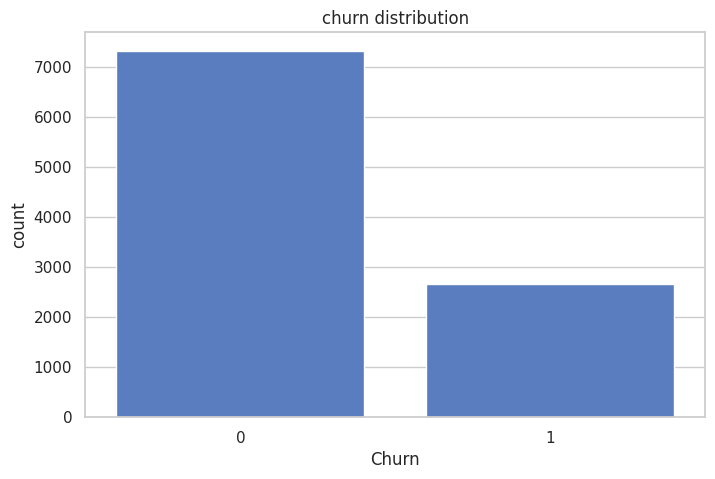

In [ ]:
#churn distribution
sns.countplot(x="Churn",data=data)
plt.title("churn distribution")
plt.show()

In [ ]:
#sns.countplot(x="Churn",data=data)  :It counts how many times each 'Churn' value appears in your data.
#plt.title("churn distribution")  :This puts a title 'churn distribution' above the chart.
#plt.show()  :This command makes the chart appear


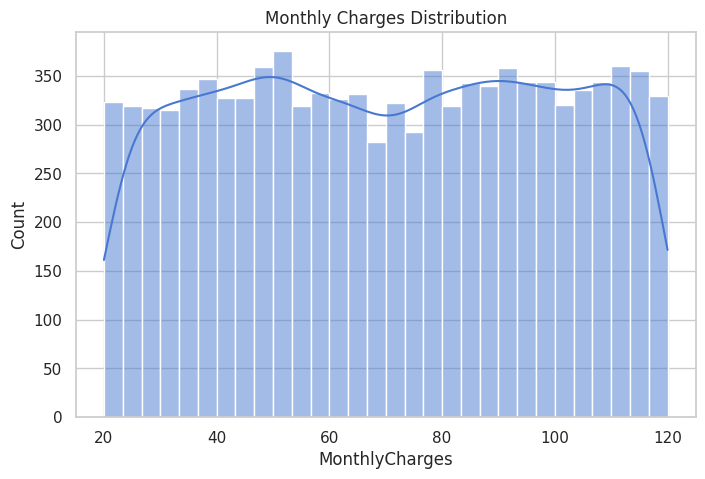

In [ ]:
# Numerical distribution
sns.histplot(data['MonthlyCharges'], bins=30, kde=True)
plt.title("Monthly Charges Distribution")
plt.show()

In [ ]:
#sns.histplot(data['MonthlyCharges'], bins=30, kde=True):draws histogram by taking MonthlyCharges from data and divide them into 30 groups and shows how many customers fall in each group
#kde=True -- adds a smooth line on top to show the general shape of the data.
#plt.title("Monthly Charges Distribution"): This puts the title "Monthly Charges Distribution" at the top of the chart.
#plt.show(): This command makes the chart appear on your screen.


In [ ]:
#Feature engineering
#convert categorical variables to numerical using one-hot encoding
#scale numerical variables
#remvove unnecessary columns(CustomerID)
# One-hot encoding
df = pd.get_dummies(data.drop('CustomerID', axis=1), drop_first=True)

# Split features & target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Scale numerical features
scaler = StandardScaler()
X[['Tenure', 'MonthlyCharges', 'TotalCharges']] = scaler.fit_transform(X[['Tenure', 'MonthlyCharges', 'TotalCharges']])

In [ ]:
#df = pd.get_dummies(data.drop('CustomerID', axis=1), drop_first=True):
#data.drop('CustomerID', axis=1): First, it removes the 'CustomerID' column because it's usually just an ID and not useful for prediction.
#drop_first=True: This prevents creating too many new columns and avoids some technical issues.

#X = df.drop('Churn', axis=1)  : This line separates your data into two main parts.
#y = df['Churn']  : y will contain the 'target' or 'what you want to predict' (in this case, whether a customer will 'Churn' or not).
#scaler = StandardScaler()  :This prepares a tool called a 'scaler', that standardizes.
#X[['Tenure', 'MonthlyCharges', 'TotalCharges']] = scaler.fit_transform(X[['Tenure', 'MonthlyCharges', 'TotalCharges']]):This line takes certain numerical columns (Tenure, MonthlyCharges, TotalCharges) and adjusts their values.


In [ ]:
#Train/Test split
#we split data into 80% training and 20% testing with preserving churn ration using stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:
#X_train, X_test, y_train, y_test = train_test_split(...):This command takes that data and cuts it into two separate piles: one for training your model and one for testing it.
#X_train and y_train are the 'training' piles that the model will learn from.
#X_test and y_test are the 'testing' piles, which the model will see only after it has learned, to see how well it performs on new, unseen data.

#X, y:These are your full set of features (X) and the target variable (y) that you want to split.
#test_size=0.2  :This means that 20% of your data will go into the 'testing' pile, and the remaining 80% will go into the 'training' pile.
#stratify=y  :This is a smart way to split the data. It makes sure that the proportion of 'Churn' (the y variable) in the training pile is roughly the same as in the testing pile. This is especially useful when one outcome (like 'Churn') is rare.
#random_state=42  :This is like setting a specific seed for a random number generator. If you run this code multiple times with random_state=42, you'll always get the exact same split of data. This helps make your results consistent and reproducible.

In [ ]:
#Model training: Logistic regression(baseline), XGBoost(advanced)
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

# XGBoost
xgb = XGBClassifier(eval_metric='logloss')
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
#lr = LogisticRegression(max_iter=1000): This line sets up a Logistic Regression model. It's a basic but powerful model for classifying things (like predicting 'Churn' or 'No Churn'). max_iter=1000 just tells it to try up to 1000 times to find the best fit.
#lr.fit(X_train, y_train): This command makes the Logistic Regression model 'learn' from your training data (X_train are the features, y_train is what it needs to predict).

#xgb = XGBClassifier(eval_metric='logloss'): This sets up an XGBoost model. This is a more advanced and often very accurate model. eval_metric='logloss' tells it how to measure its performance during training.
#xgb.fit(X_train, y_train): Similar to before, this command makes the XGBoost model 'learn' from the same training data.

Logistic Regression Results:
Confusion Matrix:
[[1466    0]
 [ 534    0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.73      1.00      0.85      1466
           1       0.00      0.00      0.00       534

    accuracy                           0.73      2000
   macro avg       0.37      0.50      0.42      2000
weighted avg       0.54      0.73      0.62      2000

AUC-ROC: 0.4640


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


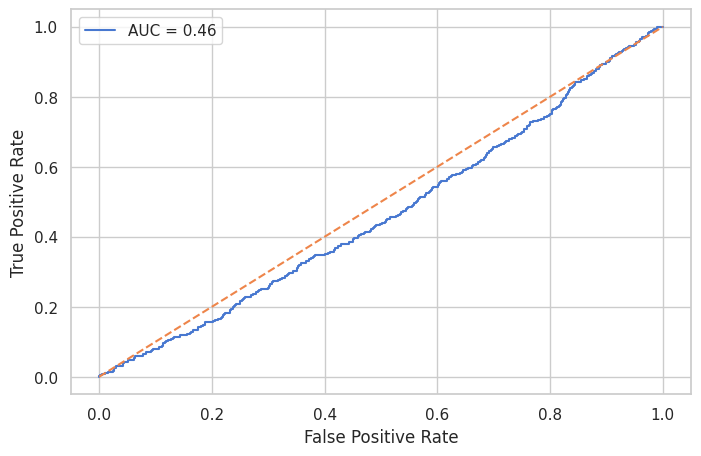

XGBoost Results:
Confusion Matrix:
[[1375   91]
 [ 501   33]]

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.94      0.82      1466
           1       0.27      0.06      0.10       534

    accuracy                           0.70      2000
   macro avg       0.50      0.50      0.46      2000
weighted avg       0.61      0.70      0.63      2000

AUC-ROC: 0.4909


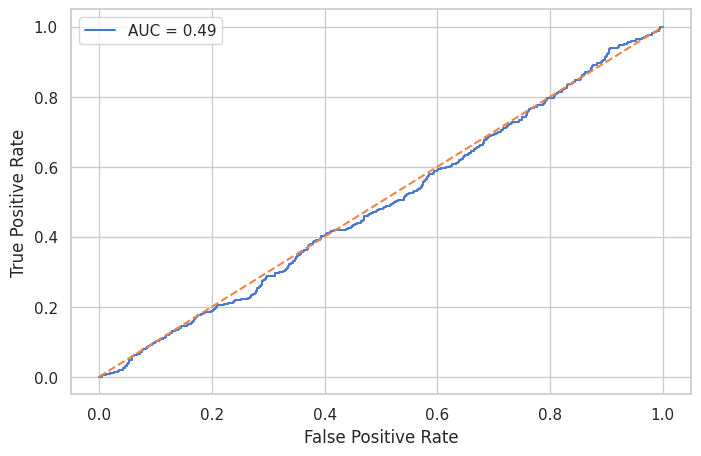

In [ ]:
#Model evaluation: confusion matrix, classification report, AUC-ROC curve
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.2f}")
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

print("Logistic Regression Results:")
evaluate_model(lr, X_test, y_test)

print("XGBoost Results:")
evaluate_model(xgb, X_test, y_test)

In [ ]:
#This code defines a function evaluate_model to check how well a machine learning model performed.
#It calculates metrics like Confusion Matrix, Classification Report, and AUC-ROC score, and also visualizes the AUC-ROC curve.
# Finally, it uses this function to show the results for both the Logistic Regression and XGBoost models trained.

